# Libraries

In [117]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

df = pd.read_csv('finance_economics_dataset.csv')

from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose


## Data Filtering
### Type

In [118]:
df.describe()
df.columns
df.dtypes
df.isnull().sum() 
df.duplicated().sum()

,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),Interest Rate (%),Consumer Confidence Index,...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
count,3000.000000,3000.000000,3000.000000,3000.00000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2982.094607,2981.249173,3018.887777,2944.32975,5.033864e+08,2.608903,5.096830,8.663787,5.218237,85.036000,...,1.146113,115.115233,85.539953,1655.167877,300.554457,5099.546667,5.007413,24.598667,49.955197,7551.278000
std,1151.862689,1151.783841,1151.683485,1151.83490,2.859004e+08,4.287337,2.910513,3.737536,2.726115,20.224829,...,0.201128,20.111351,37.847063,492.177706,114.601328,2898.714108,2.866466,14.301344,28.722592,4203.705678
min,1000.050000,954.520000,1012.130000,917.17000,1.636024e+06,-5.000000,0.010000,2.000000,0.500000,50.000000,...,0.800000,80.010000,20.040000,800.160000,100.130000,107.000000,0.010000,0.000000,0.100000,101.000000
25%,1994.982500,1997.425000,2035.952500,1955.39750,2.545224e+08,-1.012500,2.607500,5.450000,2.890000,68.000000,...,0.980000,98.267500,52.590000,1226.737500,202.370000,2503.750000,2.570000,12.000000,25.762500,3950.750000
50%,2970.780000,2977.180000,3006.520000,2939.24500,5.033710e+08,2.725000,5.110000,8.710000,5.250000,86.000000,...,1.140000,114.795000,85.080000,1666.060000,299.885000,5123.500000,5.060000,25.000000,49.840000,7610.000000
75%,3974.690000,3982.082500,4015.217500,3934.08750,7.537963e+08,6.242500,7.600000,11.882500,7.492500,103.000000,...,1.320000,132.455000,119.150000,2080.730000,399.137500,7616.250000,7.482500,37.000000,74.825000,11148.750000
max,4998.230000,5034.130000,5076.190000,4977.06000,9.999771e+08,10.000000,10.000000,15.000000,10.000000,119.000000,...,1.500000,149.960000,149.870000,2499.660000,499.920000,9998.000000,10.000000,49.000000,99.990000,14990.000000


Index(['Date', 'Stock Index', 'Open Price', 'Close Price', 'Daily High',
       'Daily Low', 'Trading Volume', 'GDP Growth (%)', 'Inflation Rate (%)',
       'Unemployment Rate (%)', 'Interest Rate (%)',
       'Consumer Confidence Index', 'Government Debt (Billion USD)',
       'Corporate Profits (Billion USD)', 'Forex USD/EUR', 'Forex USD/JPY',
       'Crude Oil Price (USD per Barrel)', 'Gold Price (USD per Ounce)',
       'Real Estate Index', 'Retail Sales (Billion USD)',
       'Bankruptcy Rate (%)', 'Mergers & Acquisitions Deals',
       'Venture Capital Funding (Billion USD)',
       'Consumer Spending (Billion USD)'],
      dtype='object')

Date                                      object
Stock Index                               object
Open Price                               float64
Close Price                              float64
Daily High                               float64
Daily Low                                float64
Trading Volume                             int64
GDP Growth (%)                           float64
Inflation Rate (%)                       float64
Unemployment Rate (%)                    float64
Interest Rate (%)                        float64
Consumer Confidence Index                  int64
Government Debt (Billion USD)              int64
Corporate Profits (Billion USD)            int64
Forex USD/EUR                            float64
Forex USD/JPY                            float64
Crude Oil Price (USD per Barrel)         float64
Gold Price (USD per Ounce)               float64
Real Estate Index                        float64
Retail Sales (Billion USD)                 int64
Bankruptcy Rate (%) 

Date                                     0
Stock Index                              0
Open Price                               0
Close Price                              0
Daily High                               0
Daily Low                                0
Trading Volume                           0
GDP Growth (%)                           0
Inflation Rate (%)                       0
Unemployment Rate (%)                    0
Interest Rate (%)                        0
Consumer Confidence Index                0
Government Debt (Billion USD)            0
Corporate Profits (Billion USD)          0
Forex USD/EUR                            0
Forex USD/JPY                            0
Crude Oil Price (USD per Barrel)         0
Gold Price (USD per Ounce)               0
Real Estate Index                        0
Retail Sales (Billion USD)               0
Bankruptcy Rate (%)                      0
Mergers & Acquisitions Deals             0
Venture Capital Funding (Billion USD)    0
Consumer Sp

np.int64(0)

### Date

In [119]:
df['Date'] = pd.to_datetime(df['Date']) # convert object to datetime

df['Date'].min(), df['Date'].max()
expect_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='D')
expect_range.difference(df['Date'])
df['Date'].duplicated().sum()


df.sort_values('Date', inplace=True) # in memory only
df.head(10)

(Timestamp('2000-01-01 00:00:00'), Timestamp('2008-03-18 00:00:00'))

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

np.int64(0)

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
0,2000-01-01,Dow Jones,2128.75,2138.48,2143.70,2100.55,2670411,-0.37,6.06,6.10,...,1.04,119.87,47.20,1052.34,390.23,2229,2.12,3,76.64,4589
1,2000-01-02,S&P 500,2046.82,2036.18,2082.83,2009.53,690220415,3.19,4.95,6.62,...,1.00,98.22,52.84,1957.73,346.23,4156,1.40,21,5.67,10101
2,2000-01-03,Dow Jones,1987.92,1985.26,2022.28,1978.37,315284661,5.54,9.13,2.60,...,0.83,80.13,78.80,2339.49,439.46,340,0.79,48,39.43,13665
3,2000-01-04,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,0.95,149.15,28.18,1308.54,213.07,8456,4.22,16,12.83,5192
4,2000-01-05,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,1.43,113.71,92.20,2210.08,405.49,1596,2.21,34,86.37,10688
5,2000-01-06,S&P 500,2087.80,2124.76,2153.18,2085.18,82664194,1.42,6.08,3.24,...,1.39,140.00,60.23,2338.39,441.06,403,0.82,45,96.80,8613
6,2000-01-07,Dow Jones,4037.59,3996.40,4055.78,3948.97,653722138,7.64,6.24,4.52,...,0.92,138.80,29.30,1309.15,319.60,4874,9.55,31,32.63,1303
7,2000-01-08,NASDAQ,2798.96,2826.64,2864.47,2766.89,423890033,7.08,4.39,13.01,...,1.06,136.86,117.92,896.46,265.51,1011,7.33,37,98.89,3771
8,2000-01-09,Dow Jones,4106.84,4141.59,4154.46,4062.99,867172199,5.97,4.87,9.42,...,1.02,112.13,104.95,2358.55,479.46,5193,5.18,30,75.26,13164
9,2000-01-10,Dow Jones,1261.46,1229.64,1296.14,1195.84,174582201,1.95,9.60,10.24,...,0.90,142.71,123.15,1361.82,167.59,6147,7.43,24,0.22,13774


## Correlation
Adjust Parameters and Run All to see result

In [120]:
# Set parameters
SAMPLE_RATE = 'QE' # D, ME, QE, Y
THRESHOLD = 0.05

<Figure size 1400x1200 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Financial Features (QE)')

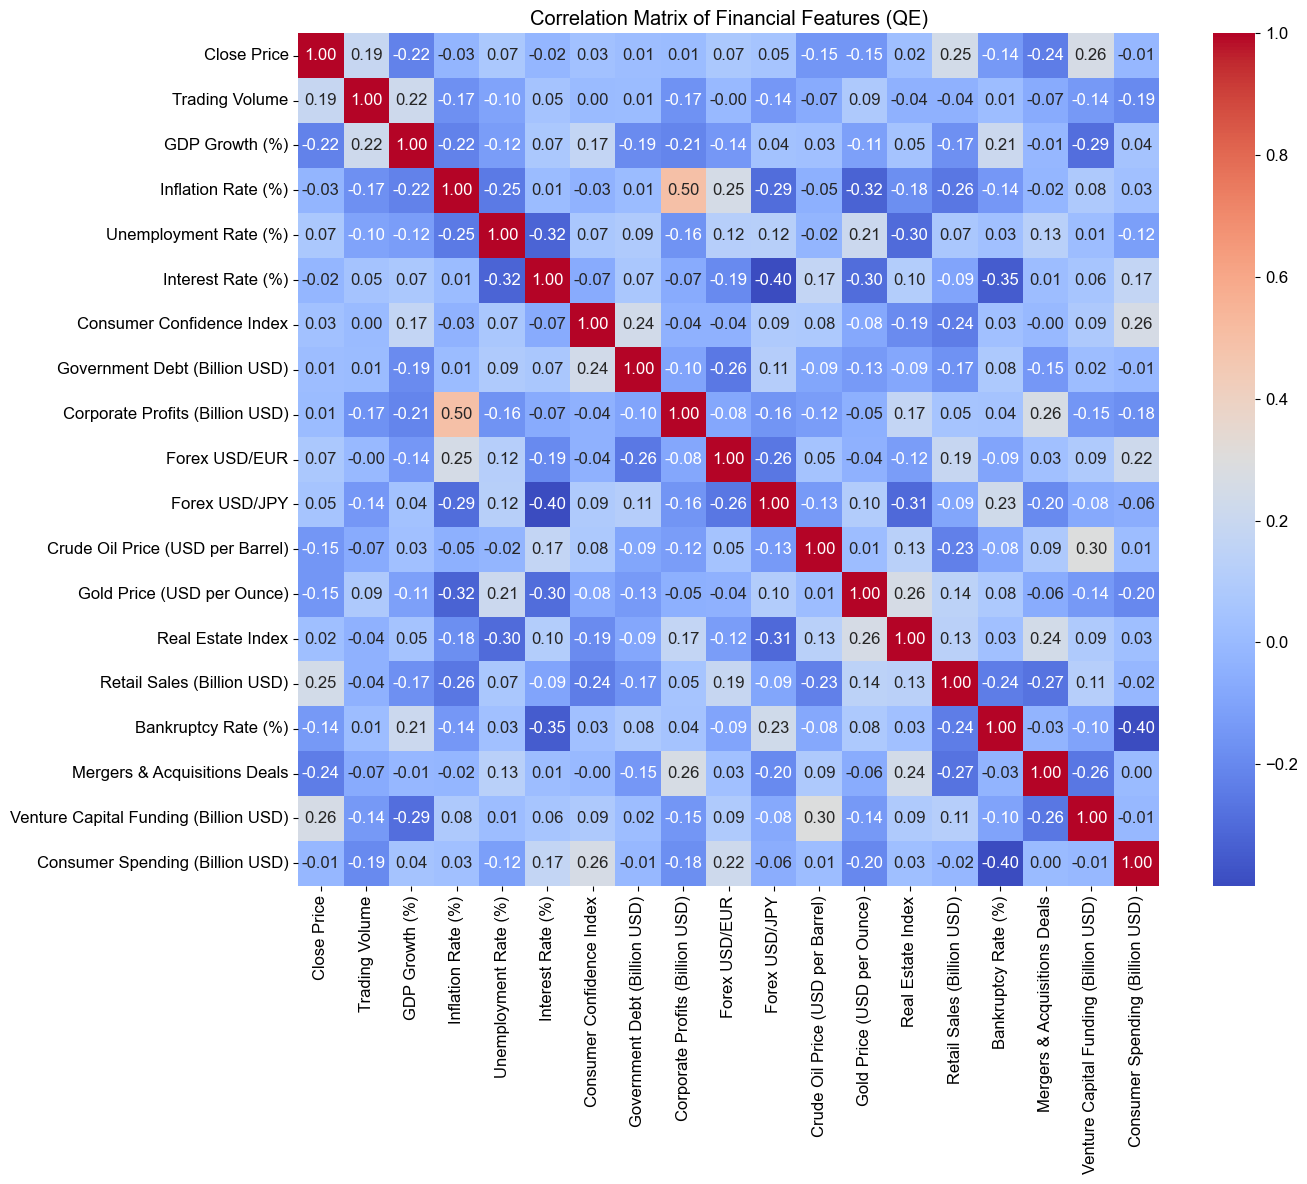

<Figure size 1400x1200 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Financial Features (QE, Threshold=0.05)')

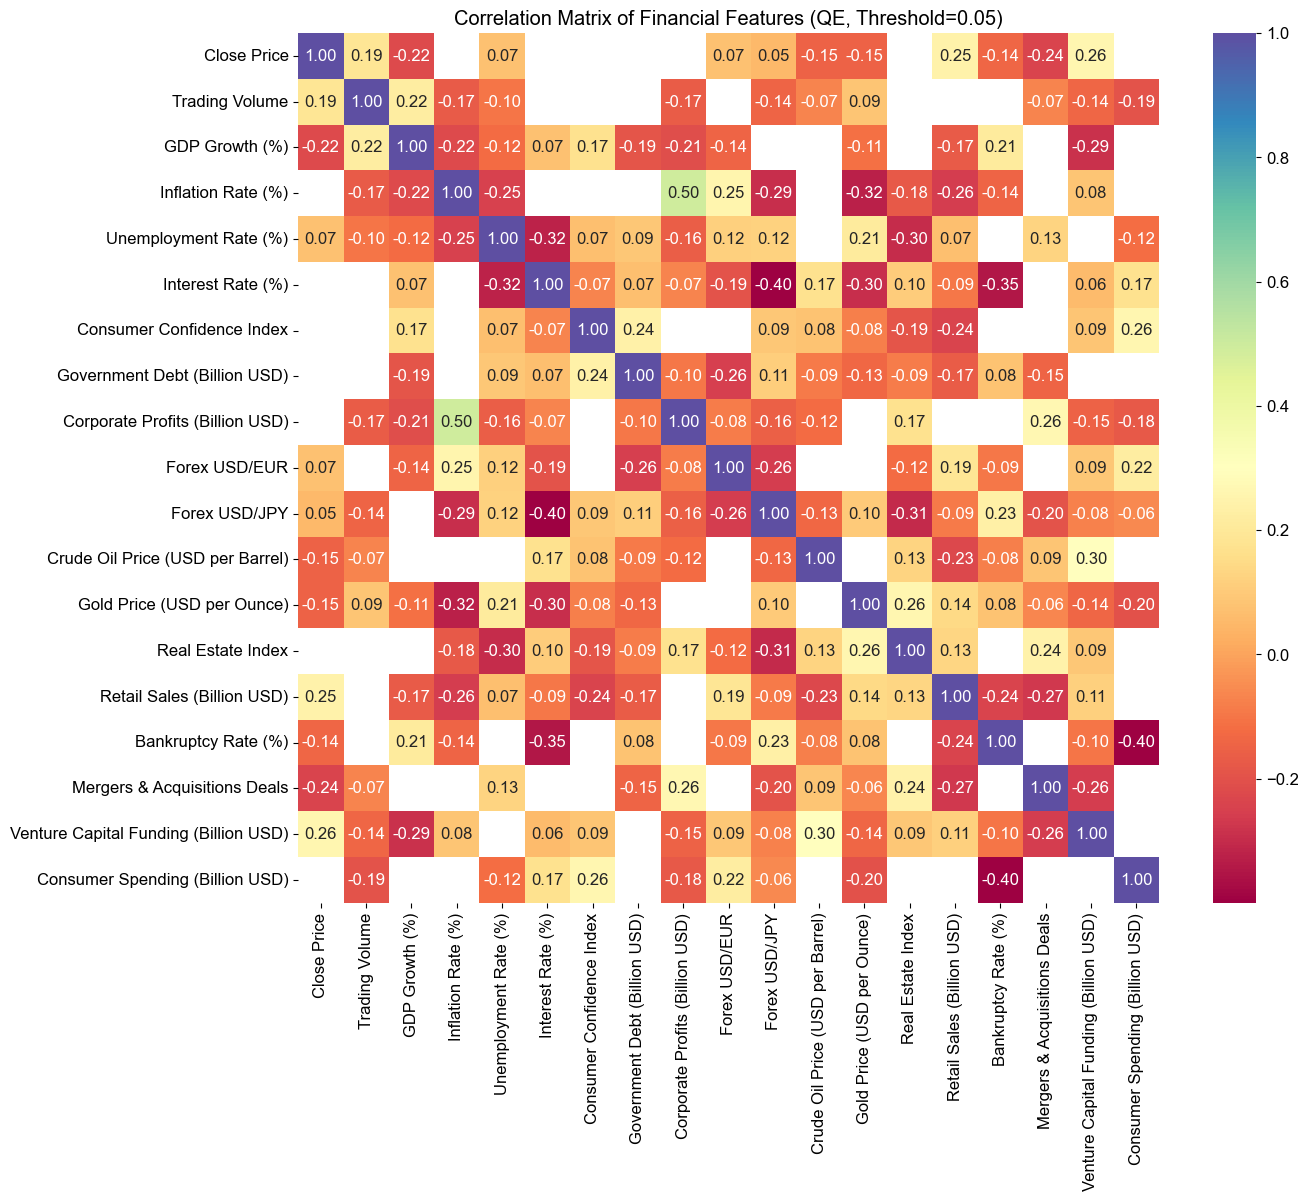

In [121]:
#plot setting
plt.rcParams['font.family'] = 'Arial'   
plt.rcParams['font.size'] = 12  

df_corr = df.resample(SAMPLE_RATE, on='Date').mean(numeric_only=True).reset_index()

correlation_matrix = df_corr.select_dtypes(include=[np.number]).corr()

# Dropped cus not relevant
cols_drop = ['Open Price','Daily High','Daily Low'] 
correlation_matrix.drop(index=cols_drop, columns=cols_drop, inplace=True)


plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title(f"Correlation Matrix of Financial Features ({SAMPLE_RATE})")
plt.tight_layout()
plt.show()

# Filtered correlation
filtered_corr = correlation_matrix[abs(correlation_matrix)>=THRESHOLD]

plt.figure(figsize=(14, 12))
sns.heatmap(filtered_corr, annot=True, cmap="Spectral", fmt=".2f")

plt.tight_layout()
plt.title(f"Correlation Matrix of Financial Features ({SAMPLE_RATE}, Threshold={THRESHOLD})")
plt.show()

## List of strongest correlations

In [122]:
NUM = 15

In [123]:
cpairs = (
    correlation_matrix.unstack()
    .reset_index()
    .rename(columns={'level_0':'Var1', 'level_1':'Var2', 0:'Correlation'})
)

# drop duplciates/self-correlation
cpairs = cpairs[cpairs['Var1'] < cpairs['Var2']]

csorted = cpairs.sort_values('Correlation', ascending=False)

print(f"Top {NUM} Positive Correlations:")
csorted.head(NUM)

print(f"Top {NUM} Negative Correlations:")
csorted.tail(NUM)

Top 15 Positive Correlations:


,Var1,Var2,Correlation
155,Corporate Profits (Billion USD),Inflation Rate (%),0.496213
226,Crude Oil Price (USD per Barrel),Venture Capital Funding (Billion USD),0.296437
168,Corporate Profits (Billion USD),Mergers & Acquisitions Deals,0.262539
132,Consumer Confidence Index,Consumer Spending (Billion USD),0.260885
241,Gold Price (USD per Ounce),Real Estate Index,0.257701
17,Close Price,Venture Capital Funding (Billion USD),0.256613
174,Forex USD/EUR,Inflation Rate (%),0.254110
14,Close Price,Retail Sales (Billion USD),0.245473
317,Mergers & Acquisitions Deals,Real Estate Index,0.242106
121,Consumer Confidence Index,Government Debt (Billion USD),0.235501


Top 15 Negative Correlations:


,Var1,Var2,Correlation
178,Forex USD/EUR,Government Debt (Billion USD),-0.256872
71,Inflation Rate (%),Retail Sales (Billion USD),-0.259473
181,Forex USD/EUR,Forex USD/JPY,-0.262268
321,Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),-0.262685
318,Mergers & Acquisitions Deals,Retail Sales (Billion USD),-0.270456
55,GDP Growth (%),Venture Capital Funding (Billion USD),-0.287276
193,Forex USD/JPY,Inflation Rate (%),-0.291323
233,Gold Price (USD per Ounce),Interest Rate (%),-0.295588
251,Real Estate Index,Unemployment Rate (%),-0.297807
203,Forex USD/JPY,Real Estate Index,-0.306158


# Prediction

In [124]:
# List of dataframes
print(df.columns)

Index(['Date', 'Stock Index', 'Open Price', 'Close Price', 'Daily High',
       'Daily Low', 'Trading Volume', 'GDP Growth (%)', 'Inflation Rate (%)',
       'Unemployment Rate (%)', 'Interest Rate (%)',
       'Consumer Confidence Index', 'Government Debt (Billion USD)',
       'Corporate Profits (Billion USD)', 'Forex USD/EUR', 'Forex USD/JPY',
       'Crude Oil Price (USD per Barrel)', 'Gold Price (USD per Ounce)',
       'Real Estate Index', 'Retail Sales (Billion USD)',
       'Bankruptcy Rate (%)', 'Mergers & Acquisitions Deals',
       'Venture Capital Funding (Billion USD)',
       'Consumer Spending (Billion USD)'],
      dtype='object')


## MAE / RMSE/ MAPE

Rank models by accuracy and interpretability for policy vs. financial forecasting

In [133]:
target = "Close Price"


features = [
    "Close Price"
]


df = df.copy()
df["Target"] = df[target].shift(-1)

# Drop rows with NaN in Target
df = df.dropna(subset=["Target"])

X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
};

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {}
    metrics["Model"] = name
    metrics["MAE"] = mean_absolute_error(y_test, y_pred)
    metrics["RMSE"] = np.sqrt(mean_squared_error(y_test, y_pred))
    metrics["MAPE (%)"] = mean_absolute_percentage_error(y_test, y_pred) * 100
    metrics["R²"] = r2_score(y_test, y_pred)

    results.append(metrics)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE")

results_df



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


,alpha,0.001
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


,Model,MAE,RMSE,MAPE (%),R²
0,Linear Regression,32.062241,37.232005,54.976389,0.00026
1,Ridge Regression,32.062241,37.232005,54.976389,0.00026
2,Lasso Regression,32.062243,37.232007,54.976393,0.00026


# Visualization
## Trend plot

<Figure size 1000x400 with 0 Axes>

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Value')

Text(0.5, 1.0, 'Actual vs Predicted (Close Price)')

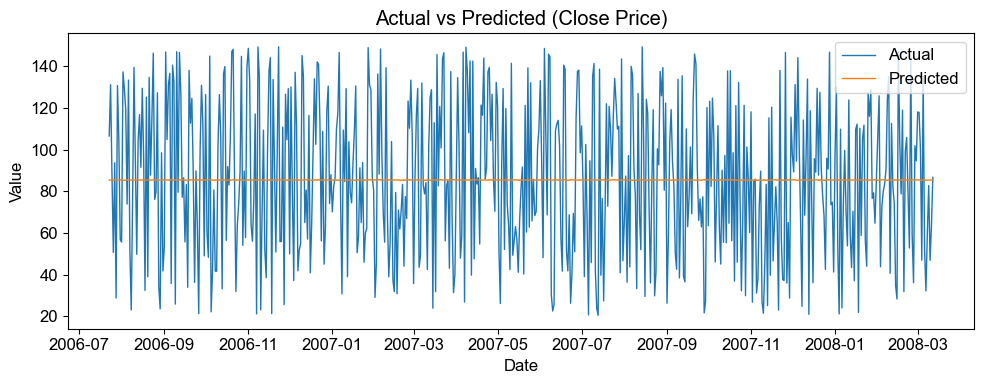

In [134]:
test_dates = df.loc[X_test.index, "Date"]

forecast_df = pd.DataFrame({
    "Date": test_dates,
    "Actual": y_test.values,
    "Predicted": y_pred
})

forecast_df = forecast_df.sort_values("Date")

plt.figure(figsize=(10, 4))
plt.plot(forecast_df["Date"], forecast_df["Actual"], label="Actual", linewidth=1)
plt.plot(forecast_df["Date"], forecast_df["Predicted"], label="Predicted", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Actual vs Predicted (Close Price)")
plt.legend()
plt.tight_layout()
plt.show()


## Confidence Interval

'\nz-score   \n\n90% - 1.645\n95% - 1.96\n99% - 2.576\n'

<Figure size 1000x400 with 0 Axes>

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Value')

Text(0.5, 1.0, 'Forecast with Approximate 95% Confidence Interval')

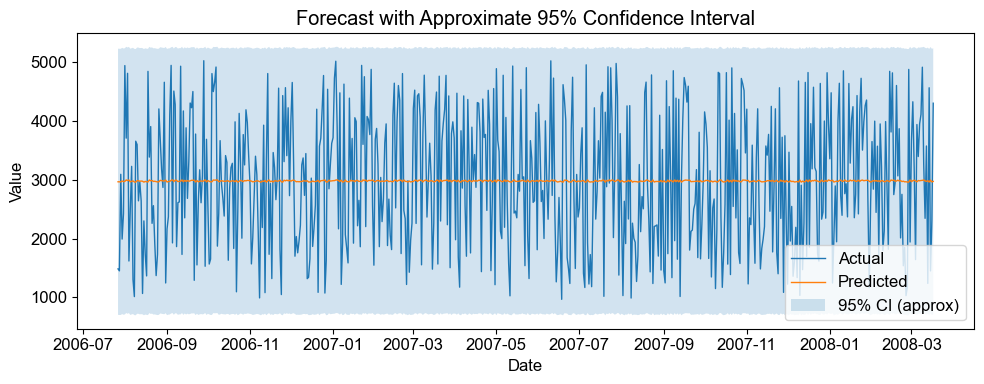

In [127]:

'''
z-score   

90% - 1.645
95% - 1.96
99% - 2.576
'''

residuals = y_test.values - y_pred
sigma = residuals.std()

upper = y_pred + 1.96 * sigma
lower = y_pred - 1.96 * sigma

plt.figure(figsize=(10, 4))
plt.plot(forecast_df["Date"], forecast_df["Actual"], label="Actual", linewidth=1)
plt.plot(forecast_df["Date"], forecast_df["Predicted"], label="Predicted", linewidth=1)


plt.fill_between(
    forecast_df["Date"],
    lower,
    upper,
    alpha=0.2,
    label="95% CI (approx)"
)

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Forecast with Approximate 95% Confidence Interval")
plt.legend()
plt.tight_layout()
plt.show()


## Decomposition Chart

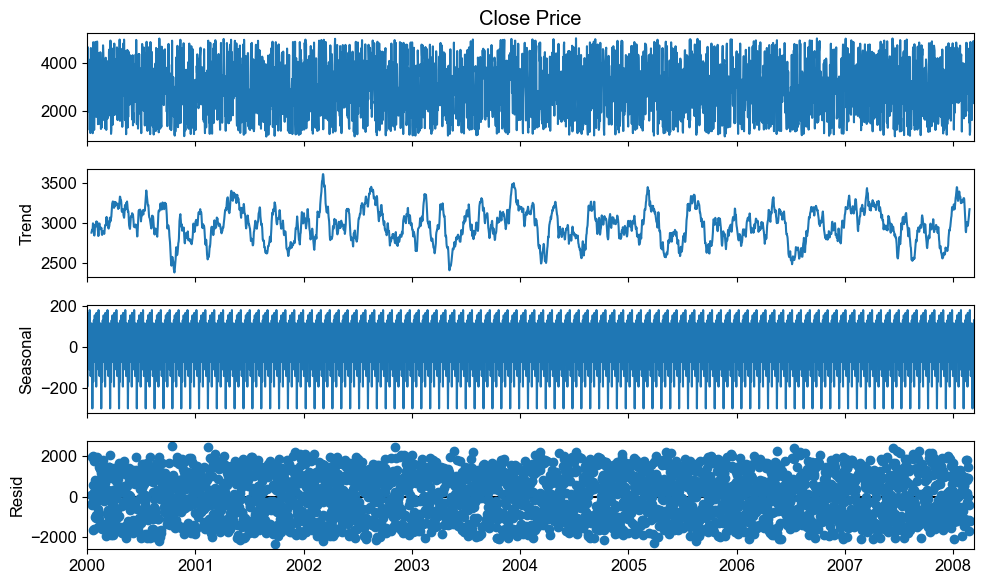

In [135]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = df.copy()
ts = ts.sort_values("Date")


ts = ts.set_index("Date")


series = ts["Close Price"].astype(float)

series = series.asfreq("D") 
series = series.interpolate()


decomp = seasonal_decompose(series, model="additive", period=30)

fig = decomp.plot()
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.show()
